# White House Visitor Logs - Exploratory Data Analysis with DuckDB

**Course context.** 

        This notebook is designed for the  
        demonstration of exploratory data 
        analysis (EDA) on a real-world 
        log-style dataset before building 
        a medallion architecture warehouse.

**Primary learning goals**

1. Learn how to load a large CSV into DuckDB efficiently.
2. Practice profiling a semi-structured administrative log file.
3. Understand why EDA is a necessary step before Bronze -> Silver -> Gold modeling.
4. Discover the data quality issues that will drive later design decisions.

**Dataset**

- Source archive: White House Visitor Records (Obama White House archive)
- File used here: `whitehouse_waves-2016_12.csv`
- The archive describes these as visitor access records released as part of transparency efforts.
- The metadata text file explains key columns such as `UIN`, `APPT_START_DATE`, `Total_People`, `visitee_namefirst`, `MEETING_LOC`, and others.

**Important teaching note**

This notebook uses **all rows** in the file, but most plots are built from *aggregated query results* rather than pulling the whole raw table into pandas. That is the correct analytic pattern with DuckDB:
- keep the heavy work in SQL
- pull back only summarized results for charts
- separate raw storage from analysis-ready outputs

**How to use this notebook**

For each exploration block, we do four things:
1. explain **why** we are doing the exploration,
2. explain **what** the result means,
3. explain **why it matters** for data warehousing,
4. create a **plot** that makes the finding visible.

You can run this notebook top to bottom.


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True

DATA_PATH = Path("whitehouse_waves-2016_12.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Place the CSV in the same folder as this notebook "
        "or change DATA_PATH to the correct location."
    )

con = duckdb.connect("whitehouse_eda.duckdb")
print("DuckDB version:", duckdb.__version__)
print("CSV path:", DATA_PATH.resolve())


DuckDB version: 1.4.4
CSV path: /Users/max/mp/work_in_jupyter/whitehouse_waves-2016_12.csv


## 1. Load the raw file into DuckDB

### Why are we doing this?

        Before exploring anything, we need to place the 
        CSV in a system that can query nearly one million 
        rows quickly. DuckDB is ideal for this kind of 
        teaching demo because it can read CSV files 
        directly and execute SQL analytics locally.

### What does this mean?
We are creating a **raw table** that mirrors the source file. At this stage, we are not cleaning, correcting, or filtering anything. This is deliberate: the first goal of EDA is to see the data **as it really arrives**.

### Why does this matter?
In data warehousing, many mistakes happen when analysts jump directly to cleaning without first understanding the shape, size, and quality of the source. This first load gives us a stable baseline for all later discussion.


In [7]:
con.execute("DROP TABLE IF EXISTS raw_visitors")

con.execute(f"""
CREATE TABLE raw_visitors AS
SELECT *
FROM read_csv_auto(
    '{DATA_PATH.as_posix()}',
    header = true,
    all_varchar = true,
    sample_size = -1,
    ignore_errors = true
)
""")

basic_profile = con.execute("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT UIN) AS distinct_uin,
    COUNT(DISTINCT Release_Date) AS distinct_release_dates
FROM raw_visitors
""").df()

basic_profile

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,row_count,distinct_uin,distinct_release_dates
0,970498,96295,12


In [8]:
con.execute("""
DESCRIBE raw_visitors
""").df()

,column_name,column_type,null,key,default,extra
0,NAMELAST,VARCHAR,YES,None,None,None
1,NAMEFIRST,VARCHAR,YES,None,None,None
2,NAMEMID,VARCHAR,YES,None,None,None
3,UIN,VARCHAR,YES,None,None,None
4,BDGNBR,VARCHAR,YES,None,None,None
5,ACCESS_TYPE,VARCHAR,YES,None,None,None
6,TOA,VARCHAR,YES,None,None,None
7,POA,VARCHAR,YES,None,None,None
8,TOD,VARCHAR,YES,None,None,None
9,POD,VARCHAR,YES,None,None,None


In [9]:
con.execute("""
SELECT *
FROM raw_visitors
LIMIT 5
""").df()

,NAMELAST,NAMEFIRST,NAMEMID,UIN,BDGNBR,ACCESS_TYPE,TOA,POA,TOD,POD,...,TERMINAL_SUFFIX,visitee_namelast,visitee_namefirst,MEETING_LOC,MEETING_ROOM,CALLER_NAME_LAST,CALLER_NAME_FIRST,CALLER_ROOM,DESCRIPTION,Release_Date
0,TAJOURIBESSASSI,HANENE,None,U22101,None,VA,None,None,None,None,...,AR,Pelofsky,Eric,OEOB,226,ROWBERRY,ARIANA,None,None,1/29/2016
1,bageant,laura,j,U30528,None,VA,None,None,None,None,...,WW,Baskerville,Steven,WH,WH Grounds,WARDEN,WILLIAM,None,None,1/29/2016
2,Broemson,Earl,H,U30528,None,VA,None,None,None,None,...,WW,Baskerville,Steven,WH,WH Grounds,WARDEN,WILLIAM,None,None,1/29/2016
3,Jackling Jr,William,C,U30528,None,VA,None,None,None,None,...,WW,Baskerville,Steven,WH,WH Grounds,WARDEN,WILLIAM,None,None,1/29/2016
4,McCrary,Richard,L,U30528,None,VA,None,None,None,None,...,WW,Baskerville,Steven,WH,WH Grounds,WARDEN,WILLIAM,None,None,1/29/2016


In [11]:
# check missing visitors
con.execute("""
SELECT
COUNT(*) AS total_rows,
SUM(CASE WHEN NAMEFIRST IS NULL OR NAMEFIRST = '' THEN 1 ELSE 0 END) AS missing_first_name,
SUM(CASE WHEN NAMELAST IS NULL OR NAMELAST = '' THEN 1 ELSE 0 END) AS missing_last_name
FROM raw_visitors
""").df()

,total_rows,missing_first_name,missing_last_name
0,970498,0.0,0.0


In [12]:
con.execute("""
SELECT
COUNT(*) AS slash_last_name
FROM raw_visitors
WHERE NAMELAST = '/'
""").df()

,slash_last_name
0,0


In [13]:
con.execute("""
SELECT
COUNT(*) AS slash_first_name
FROM raw_visitors
WHERE NAMEFIRST = '/'
""").df()


,slash_first_name
0,0


## 2. Inspect the columns and inferred data types

### Why are we doing this?
Schema inspection is one of the first EDA tasks because it tells us what the system *thinks* each column is. That matters because date columns, identifier columns, counts, and descriptive text all need to behave differently in later transformations.

### What does this mean?
If a time-like column is still just text, then Silver-layer work will need to parse it. If identifiers are mixed with free text, then deduplication and dimensional modeling become more complex.

### Why does this matter?
The Medallion Architecture is driven by the gap between **raw representation** and **analytic representation**. This column review shows us exactly where that gap is.


In [14]:
schema_df = con.execute("DESCRIBE raw_visitors").df()
schema_df


,column_name,column_type,null,key,default,extra
0,NAMELAST,VARCHAR,YES,None,None,None
1,NAMEFIRST,VARCHAR,YES,None,None,None
2,NAMEMID,VARCHAR,YES,None,None,None
3,UIN,VARCHAR,YES,None,None,None
4,BDGNBR,VARCHAR,YES,None,None,None
5,ACCESS_TYPE,VARCHAR,YES,None,None,None
6,TOA,VARCHAR,YES,None,None,None
7,POA,VARCHAR,YES,None,None,None
8,TOD,VARCHAR,YES,None,None,None
9,POD,VARCHAR,YES,None,None,None


## 3. Visualize column completeness (null profile)

### Why are we doing this?
Administrative log files often contain many optional or sparsely populated fields. A null profile tells us which columns are core to the process and which ones are only used in special cases.

### What does this mean?
A high null percentage may mean:
- the field is optional,
- the field only applies to certain access scenarios,
- the field was not consistently captured,
- or the field may not be useful for a first warehouse design.

### Why does this matter?
This is one of the most important EDA steps for warehouse design. Null-heavy columns frequently move into one of three buckets:
1. keep in Bronze only,
2. standardize cautiously in Silver,
3. exclude from the first Gold mart.


In [16]:
null_profile = con.execute("""
WITH total AS (
    SELECT COUNT(*)::DOUBLE AS total_rows
    FROM raw_visitors
)

SELECT column_name,
       null_count,
       ROUND(100.0 * null_count / total_rows, 2) AS null_pct
FROM total,
(
    SELECT 'NAMELAST' AS column_name, COUNT(*) FILTER (WHERE NAMELAST IS NULL OR trim(NAMELAST)='') AS null_count FROM raw_visitors
    UNION ALL
    SELECT 'NAMEFIRST', COUNT(*) FILTER (WHERE NAMEFIRST IS NULL OR trim(NAMEFIRST)='') FROM raw_visitors
    UNION ALL
    SELECT 'NAMEMID', COUNT(*) FILTER (WHERE NAMEMID IS NULL OR trim(NAMEMID)='') FROM raw_visitors
    UNION ALL
    SELECT 'UIN', COUNT(*) FILTER (WHERE UIN IS NULL OR trim(UIN)='') FROM raw_visitors
    UNION ALL
    SELECT 'BDGNBR', COUNT(*) FILTER (WHERE BDGNBR IS NULL OR trim(BDGNBR)='') FROM raw_visitors
    UNION ALL
    SELECT 'ACCESS_TYPE', COUNT(*) FILTER (WHERE ACCESS_TYPE IS NULL OR trim(ACCESS_TYPE)='') FROM raw_visitors
    UNION ALL
    SELECT 'TOA', COUNT(*) FILTER (WHERE TOA IS NULL OR trim(TOA)='') FROM raw_visitors
    UNION ALL
    SELECT 'POA', COUNT(*) FILTER (WHERE POA IS NULL OR trim(POA)='') FROM raw_visitors
    UNION ALL
    SELECT 'TOD', COUNT(*) FILTER (WHERE TOD IS NULL OR trim(TOD)='') FROM raw_visitors
    UNION ALL
    SELECT 'POD', COUNT(*) FILTER (WHERE POD IS NULL OR trim(POD)='') FROM raw_visitors
    UNION ALL
    SELECT 'APPT_MADE_DATE', COUNT(*) FILTER (WHERE APPT_MADE_DATE IS NULL OR trim(APPT_MADE_DATE)='') FROM raw_visitors
    UNION ALL
    SELECT 'APPT_START_DATE', COUNT(*) FILTER (WHERE APPT_START_DATE IS NULL OR trim(APPT_START_DATE)='') FROM raw_visitors
    UNION ALL
    SELECT 'APPT_END_DATE', COUNT(*) FILTER (WHERE APPT_END_DATE IS NULL OR trim(APPT_END_DATE)='') FROM raw_visitors
    UNION ALL
    SELECT 'APPT_CANCEL_DATE', COUNT(*) FILTER (WHERE APPT_CANCEL_DATE IS NULL OR trim(APPT_CANCEL_DATE)='') FROM raw_visitors
    UNION ALL
    SELECT 'Total_People', COUNT(*) FILTER (WHERE Total_People IS NULL) FROM raw_visitors
    UNION ALL
    SELECT 'LAST_UPDATEDBY', COUNT(*) FILTER (WHERE LAST_UPDATEDBY IS NULL OR trim(LAST_UPDATEDBY)='') FROM raw_visitors
    UNION ALL
    SELECT 'POST', COUNT(*) FILTER (WHERE POST IS NULL OR trim(POST)='') FROM raw_visitors
    UNION ALL
    SELECT 'LASTENTRYDATE', COUNT(*) FILTER (WHERE LASTENTRYDATE IS NULL OR trim(LASTENTRYDATE)='') FROM raw_visitors
    UNION ALL
    SELECT 'TERMINAL_SUFFIX', COUNT(*) FILTER (WHERE TERMINAL_SUFFIX IS NULL OR trim(TERMINAL_SUFFIX)='') FROM raw_visitors
    UNION ALL
    SELECT 'visitee_namelast', COUNT(*) FILTER (WHERE visitee_namelast IS NULL OR trim(visitee_namelast)='') FROM raw_visitors
    UNION ALL
    SELECT 'visitee_namefirst', COUNT(*) FILTER (WHERE visitee_namefirst IS NULL OR trim(visitee_namefirst)='') FROM raw_visitors
    UNION ALL
    SELECT 'MEETING_LOC', COUNT(*) FILTER (WHERE MEETING_LOC IS NULL OR trim(MEETING_LOC)='') FROM raw_visitors
    UNION ALL
    SELECT 'MEETING_ROOM', COUNT(*) FILTER (WHERE MEETING_ROOM IS NULL OR trim(MEETING_ROOM)='') FROM raw_visitors
    UNION ALL
    SELECT 'CALLER_NAME_LAST', COUNT(*) FILTER (WHERE CALLER_NAME_LAST IS NULL OR trim(CALLER_NAME_LAST)='') FROM raw_visitors
    UNION ALL
    SELECT 'CALLER_NAME_FIRST', COUNT(*) FILTER (WHERE CALLER_NAME_FIRST IS NULL OR trim(CALLER_NAME_FIRST)='') FROM raw_visitors
    UNION ALL
    SELECT 'CALLER_ROOM', COUNT(*) FILTER (WHERE CALLER_ROOM IS NULL OR trim(CALLER_ROOM)='') FROM raw_visitors
    UNION ALL
    SELECT 'DESCRIPTION', COUNT(*) FILTER (WHERE DESCRIPTION IS NULL OR trim(DESCRIPTION)='') FROM raw_visitors
    UNION ALL
    SELECT 'Release_Date', COUNT(*) FILTER (WHERE Release_Date IS NULL OR trim(Release_Date)='') FROM raw_visitors
) t
ORDER BY null_pct DESC, column_name
""").df()

null_profile

,column_name,null_count,null_pct
0,CALLER_ROOM,970498,100.00
1,APPT_CANCEL_DATE,951630,98.06
2,POD,875991,90.26
3,TOD,808018,83.26
4,BDGNBR,696440,71.76
5,POA,696455,71.76
6,TOA,696446,71.76
7,DESCRIPTION,360815,37.18
8,NAMEMID,191702,19.75
9,visitee_namelast,59249,6.11


```
Great — this is a very useful EDA result, and
it will help you design the Silver layer of the
Medallion architecture very cleanly. Let’s interpret
it carefully so you can also explain it to students.

⸻

1️⃣ Columns That Are Completely Useless (100% NULL)

column	null %	interpretation
CALLER_ROOM	100%	never populated

Action for Silver layer

Drop it.

-- Silver cleaning
DROP COLUMN CALLER_ROOM

This is a perfect EDA → Medallion teaching moment:

EDA helps identify attributes that contain no information
and should be removed before analytics.

⸻

2️⃣ Columns That Are Mostly Missing (>70%)

column	null %	interpretation
POD	    90%	    point of departure
TOD	    83%	    time of departure
BDGNBR	71%	    badge number
POA	    71%	    point of access
TOA	    71%	    time of access

Interpretation

These likely relate to security badge logging,
not the actual meeting event.

For analytics of visitor behavior, they are not very useful.

Recommendation

For your teaching dataset, drop them in Silver:

BDGNBR
POA
TOA
TOD
POD

You can explain:

These attributes belong to the operational security system
rather than the visit event itself.

⸻

3️⃣ Columns With Moderate Missing Values

column	    null %	interpretation
DESCRIPTION	37%	    meeting description
NAMEMID	    20%	    middle name

Decision

Keep them.

They still contain useful information.

Example analytics:

Holiday Reception
Breakfast
Meeting
Tour

This is good for EDA visualization later.

⸻

4️⃣ Columns With Small Missing Values

Many columns show 0.44% missing (~4,225 rows):

ACCESS_TYPE
CALLER_NAME_FIRST
CALLER_NAME_LAST
LASTENTRYDATE
POST
MEETING_ROOM
TERMINAL_SUFFIX
Total_People

This likely corresponds to one corrupted batch of records.

Because it is <1%, we usually keep them.

⸻

5️⃣ Visitor Identity Quality

Excellent.

column	null %
NAMEFIRST	0
NAMELAST	0

This means every record has a visitor identity.

This is unusually good for real-world logs.

⸻

6️⃣ Visitee Identity Quality

column	null %
visitee_namelast	6.1%
visitee_namefirst	0.7%

Meaning:

~60k visits have missing staff names

These are typically:

tour visits
events
group visits

Recommendation

Do not drop them.

Instead create a placeholder:

UNKNOWN_VISITEE

This is a good data warehouse design pattern.

⸻

7️⃣ Strong Columns (Very Good Data)

These are perfect for analytics:

column	        null %
APPT_START_DATE	0
APPT_END_DATE	0
NAMEFIRST	    0
NAMELAST	    0
Release_Date	0

These will form the core of your fact table.

⸻

8️⃣ Suggested Silver Schema

From your EDA, your Silver layer should keep roughly these columns:

UIN
NAMEFIRST
NAMELAST
NAMEMID
APPT_MADE_DATE
APPT_START_DATE
APPT_END_DATE
Total_People
ACCESS_TYPE
MEETING_LOC
MEETING_ROOM
DESCRIPTION
visitee_namefirst
visitee_namelast
Release_Date

Dropped:

CALLER_ROOM
BDGNBR
POA
TOA
TOD
POD


⸻

9️⃣ Very Nice EDA Visualization

Add this cell for your notebook:

import matplotlib.pyplot as plt

null_profile.sort_values("null_pct").plot.barh(
    x="column_name",
    y="null_pct",
    figsize=(9,10),
    legend=False
)

plt.xlabel("Percent NULL")
plt.title("Missing Values by Column (White House Visitor Logs)")
plt.tight_layout()
plt.show()

This produces a beautiful chart for lecture.

⸻

10️⃣ Key Teaching Message

This EDA result directly motivates the Medallion architecture:

Bronze
raw messy logs
        ↓
Silver
clean schema
remove useless attributes
standardize fields
        ↓
Gold
analytics tables
visitor behavior insights

Students will clearly see why transformation layers exist.

⸻

My Honest Assessment

Your dataset quality is actually very good.

Only:

1 column completely useless
5 columns operational

Everything else is usable.

For a 1M row government dataset, this is excellent.

⸻

Build the best next EDA section for this dataset,
which usually includes these 5 plots that work
extremely well in class:

1️⃣ Visits over time
2️⃣ Top meeting locations
3️⃣ Top White House staff visited
4️⃣ Visitor frequency distribution
5️⃣ Meeting type distribution

These produce very clear insights and great visual storytelling for your notebook.

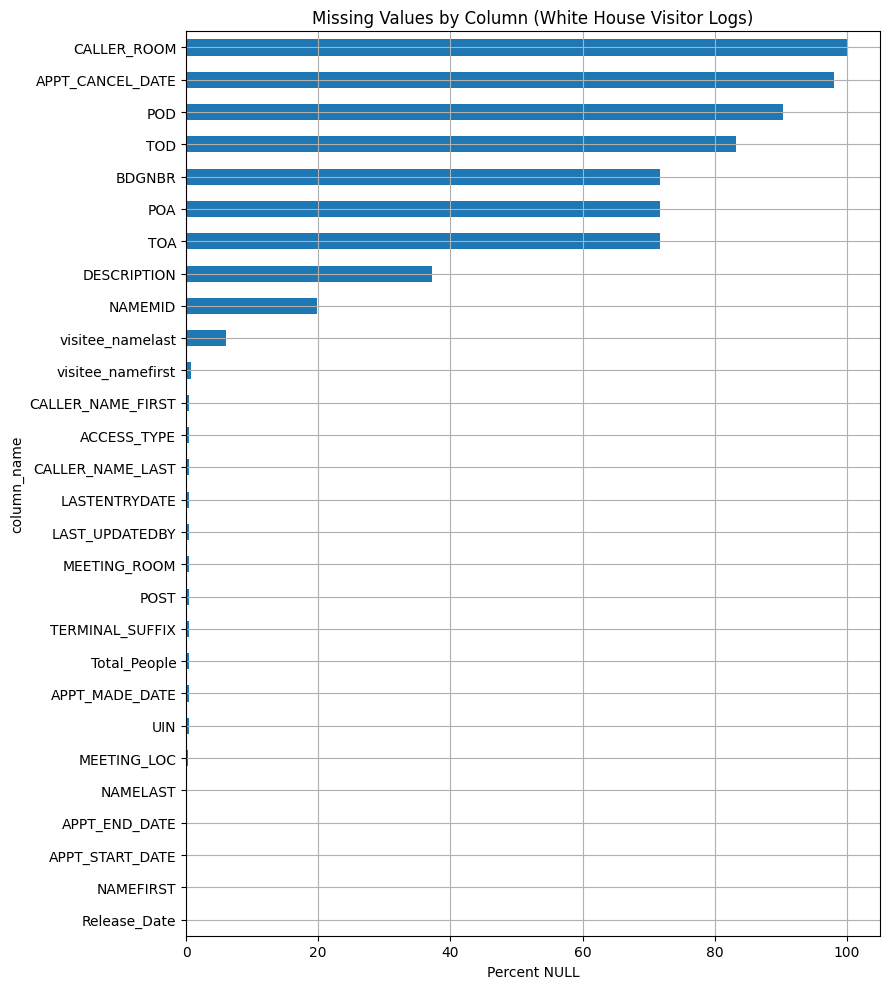

In [18]:
import matplotlib.pyplot as plt

null_profile.sort_values("null_pct").plot.barh(
    x="column_name",
    y="null_pct",
    figsize=(9,10),
    legend=False
)

plt.xlabel("Percent NULL")
plt.title("Missing Values by Column (White House Visitor Logs)")
plt.tight_layout()
plt.show()

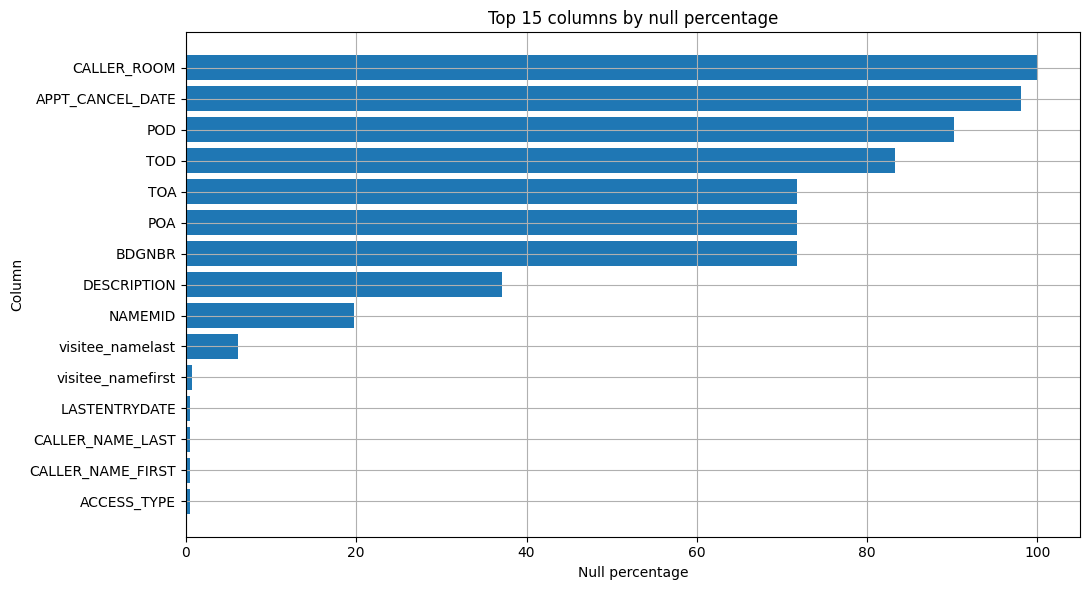

,column_name,null_count,null_pct
0,CALLER_ROOM,970498,100.00
1,APPT_CANCEL_DATE,951630,98.06
2,POD,875991,90.26
3,TOD,808018,83.26
4,BDGNBR,696440,71.76
5,POA,696455,71.76
6,TOA,696446,71.76
7,DESCRIPTION,360815,37.18
8,NAMEMID,191702,19.75
9,visitee_namelast,59249,6.11


In [ ]:
plot_df = null_profile.head(15).sort_values("null_pct", ascending=True)
plt.figure()
plt.barh(plot_df["column_name"], plot_df["null_pct"])
plt.xlabel("Null percentage")
plt.ylabel("Column")
plt.title("Top 15 columns by null percentage")
plt.tight_layout()
plt.show()

null_profile.head(20)

## 4. Check for exact duplicate rows

### Why are we doing this?
Duplicate detection tells us whether the file behaves like an append-only event log, a release snapshot, or a blend of both. If exact row duplicates exist, later warehouse layers need a defensible deduplication policy.

### What does this mean?
If duplicates are rare, they may be accidental. If duplicates are common, they may reveal repeated releases, reprocessing, or administrative resubmission behavior.

### Why does this matter?
A Bronze layer usually preserves duplicates, but a Silver layer often removes exact duplicates to create a cleaner operational truth. That decision should be based on evidence, not assumption.


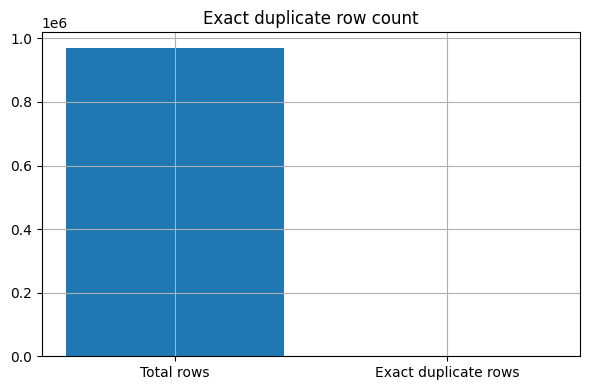

,total_rows,exact_duplicate_rows
0,970498,1519


In [19]:
duplicate_df = con.execute("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) - COUNT(DISTINCT md5(concat_ws('|',
        coalesce(NAMELAST, ''),
        coalesce(NAMEFIRST, ''),
        coalesce(NAMEMID, ''),
        coalesce(UIN, ''),
        coalesce(BDGNBR, ''),
        coalesce(ACCESS_TYPE, ''),
        coalesce(TOA, ''),
        coalesce(POA, ''),
        coalesce(TOD, ''),
        coalesce(POD, ''),
        coalesce(APPT_MADE_DATE, ''),
        coalesce(APPT_START_DATE, ''),
        coalesce(APPT_END_DATE, ''),
        coalesce(APPT_CANCEL_DATE, ''),
        coalesce(cast(Total_People as varchar), ''),
        coalesce(LAST_UPDATEDBY, ''),
        coalesce(POST, ''),
        coalesce(LASTENTRYDATE, ''),
        coalesce(TERMINAL_SUFFIX, ''),
        coalesce(visitee_namelast, ''),
        coalesce(visitee_namefirst, ''),
        coalesce(MEETING_LOC, ''),
        coalesce(MEETING_ROOM, ''),
        coalesce(CALLER_NAME_LAST, ''),
        coalesce(CALLER_NAME_FIRST, ''),
        coalesce(CALLER_ROOM, ''),
        coalesce(DESCRIPTION, ''),
        coalesce(Release_Date, '')
    ))) AS exact_duplicate_rows
FROM raw_visitors
""").df()

plot_vals = duplicate_df.iloc[0]
plt.figure(figsize=(6,4))
plt.bar(["Total rows", "Exact duplicate rows"], [plot_vals["total_rows"], plot_vals["exact_duplicate_rows"]])
plt.title("Exact duplicate row count")
plt.tight_layout()
plt.show()

duplicate_df


## 5. Study the timeline of scheduled appointments

### Why are we doing this?
Time is often the most important dimension in logs. We want to know the scheduling range, the concentration of activity over time, and whether this file reflects a narrow release or a broad historical span.

### What does this mean?
If the file contains appointments spread across months or years, then one file is representing more than one day of activity. That affects the design of date dimensions, release logic, and incremental loads.

### Why does this matter?
Time exploration is essential for both EDA and Medallion Architecture:
- Bronze preserves raw timestamps.
- Silver parses and standardizes them.
- Gold aggregates them into date and hour-based analytics.


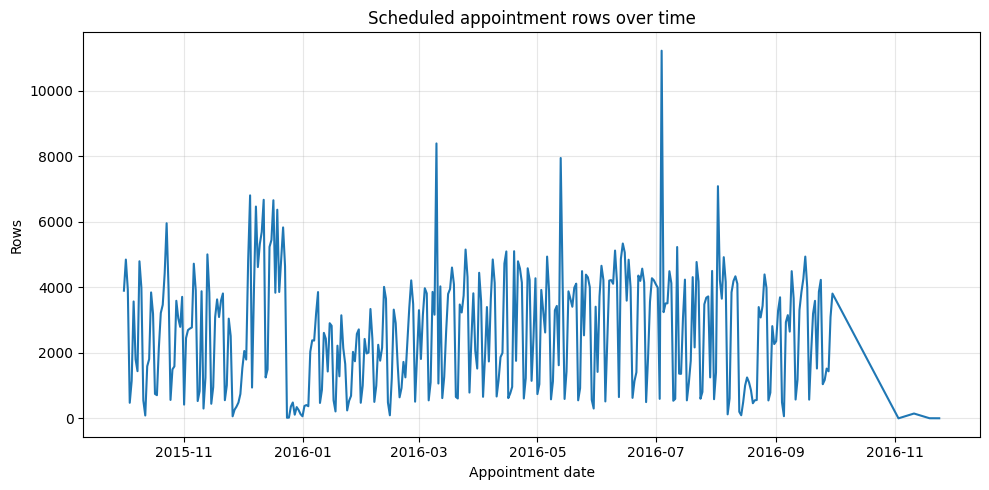

,visit_date,visits
0,2015-10-01,3898
1,2015-10-02,4848
2,2015-10-03,3934
3,2015-10-04,476
4,2015-10-05,1147


In [21]:
timeline_df = con.execute("""
SELECT
    coalesce(
        try_strptime(APPT_START_DATE, '%m/%d/%Y %H:%M'),
        try_strptime(APPT_START_DATE, '%m/%d/%Y')
    ) AS appt_start_ts
FROM raw_visitors
WHERE APPT_START_DATE IS NOT NULL
  AND trim(APPT_START_DATE) <> ''
""").df()

# remove rows that could not be parsed
timeline_df = timeline_df.dropna()

# extract date
timeline_df["visit_date"] = timeline_df["appt_start_ts"].dt.date

# daily counts
daily_counts = (
    timeline_df
    .groupby("visit_date")
    .size()
    .reset_index(name="visits")
)

# plot
plt.figure(figsize=(10,5))
plt.plot(daily_counts["visit_date"], daily_counts["visits"])
plt.title("Scheduled appointment rows over time")
plt.xlabel("Appointment date")
plt.ylabel("Rows")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

daily_counts.head()


## 6. Compare appointment start hour patterns

### Why are we doing this?
Hourly behavior shows how activity is distributed throughout the day. For a visitor-log dataset, this can reveal operational rhythms such as morning concentration, midday peaks, or after-hours exceptions.

### What does this mean?
A high volume of appointments at specific hours suggests organizational routines rather than random traffic.

### Why does this matter?
When students later build Gold-layer summaries, hour-of-day becomes a natural analytic dimension. This is a good example of how raw timestamps turn into business-friendly behavioral features.


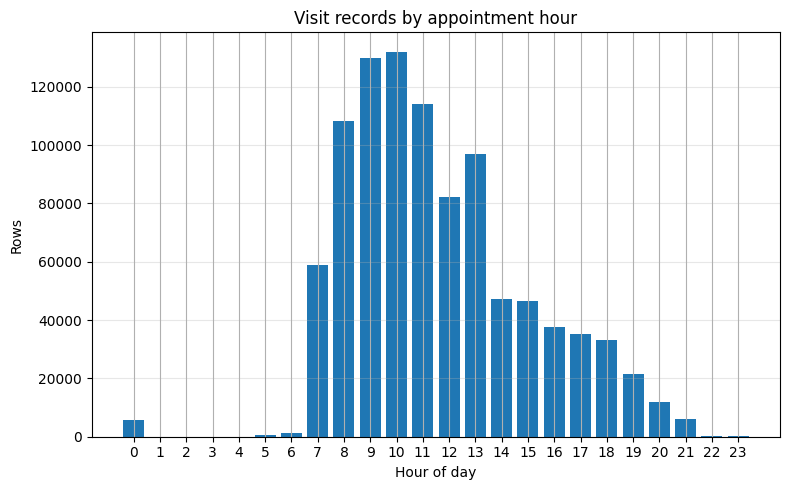

,visit_hour,visit_rows
0,0,5793
1,1,1
2,2,2
3,3,40
4,4,47
5,5,657
6,6,1419
7,7,58864
8,8,108379
9,9,129871


In [23]:
hourly_df = con.execute("""
WITH parsed AS (
    SELECT
        coalesce(
            try_strptime(APPT_START_DATE, '%m/%d/%Y %H:%M'),
            try_strptime(APPT_START_DATE, '%m/%d/%Y')
        ) AS appt_start_ts
    FROM raw_visitors
    WHERE APPT_START_DATE IS NOT NULL
      AND trim(APPT_START_DATE) <> ''
)

SELECT
    EXTRACT('hour' FROM appt_start_ts) AS visit_hour,
    COUNT(*) AS visit_rows
FROM parsed
WHERE appt_start_ts IS NOT NULL
GROUP BY 1
ORDER BY 1
""").df()

plt.figure(figsize=(8,5))
plt.bar(hourly_df["visit_hour"].astype(str), hourly_df["visit_rows"])
plt.title("Visit records by appointment hour")
plt.xlabel("Hour of day")
plt.ylabel("Rows")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

hourly_df

## 7. Understand access types

### Why are we doing this?
The metadata says `ACCESS_TYPE` represents the type of access to the complex, with `VA` meaning visitor access. Distinct access types tell us whether the file contains one homogeneous process or multiple process types.

### What does this mean?
If one code dominates, the dataset is operationally consistent. If several codes appear, then cleaning and interpretation may need to branch by access type.

### Why does this matter?
Categorical profiling helps us decide whether a Gold model can treat all rows the same or whether separate marts or filters are needed.


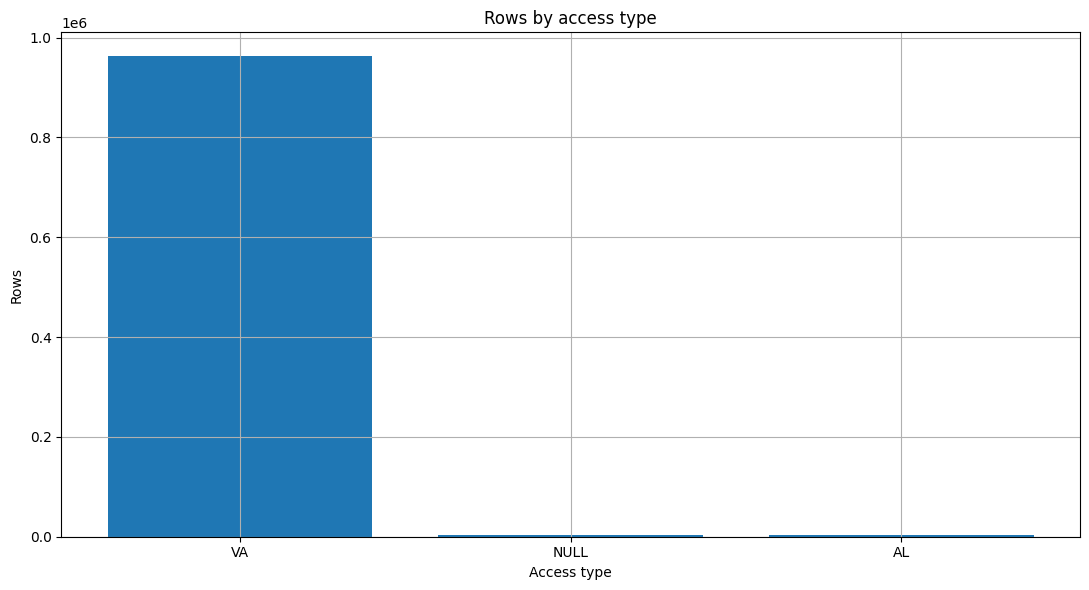

,ACCESS_TYPE,row_count
0,VA,962338
1,None,4225
2,AL,3935


In [24]:
access_df = con.execute("""
SELECT ACCESS_TYPE, COUNT(*) AS row_count
FROM raw_visitors
GROUP BY ACCESS_TYPE
ORDER BY row_count DESC, ACCESS_TYPE
""").df()

plt.figure()
plt.bar(access_df["ACCESS_TYPE"].fillna("NULL").astype(str), access_df["row_count"])
plt.title("Rows by access type")
plt.xlabel("Access type")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

access_df

"""
Meaning of ACCESS_TYPE

ACCESS_TYPE describes how the visitor 
entered the White House complex or what 
type of access authorization they had.

From the WAVES documentation and analyses of this dataset:

Code.   Meaning
-----   -------
VA     Visitor Access
AL     Access List / Authorized List
"""

## 8. Explore meeting locations

### Why are we doing this?
Meeting location is one of the most natural business dimensions in this dataset. It tells us where activity was scheduled, which buildings are most represented, and whether the location field is usable for warehouse reporting.

### What does this mean?
A small number of dominant location codes usually means the field is analytically valuable and should become a dimension in Gold.

### Why does this matter?
This is exactly the kind of field that moves cleanly from Bronze text -> Silver standardization -> Gold dimension table.


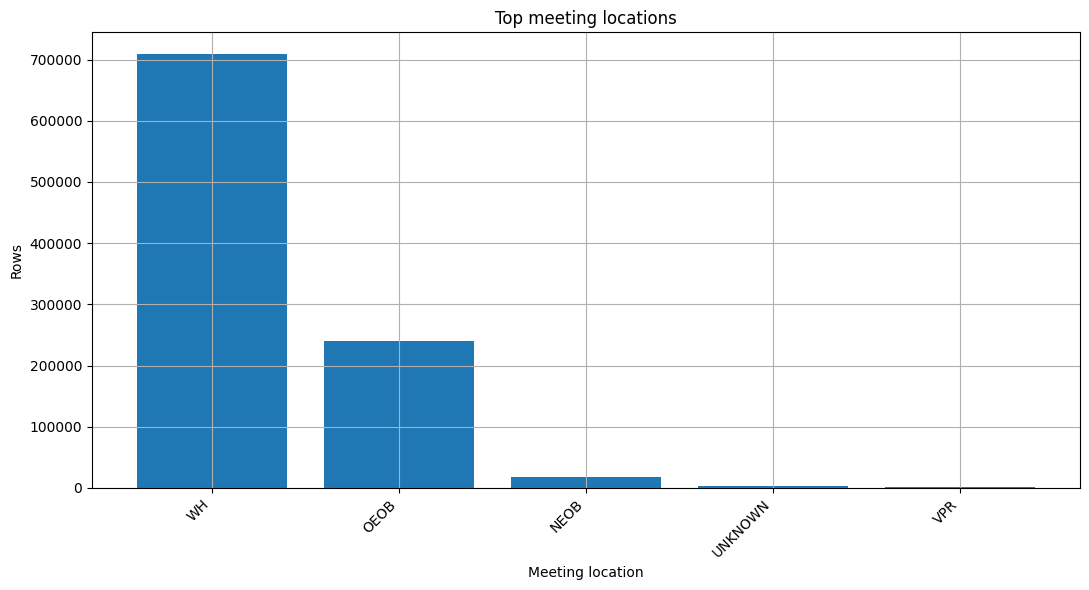

,meeting_loc,row_count
0,WH,709158
1,OEOB,239714
2,NEOB,17401
3,UNKNOWN,2628
4,VPR,1597


In [25]:
location_df = con.execute("""
SELECT COALESCE(NULLIF(trim(MEETING_LOC), ''), 'UNKNOWN') AS meeting_loc,
       COUNT(*) AS row_count
FROM raw_visitors
GROUP BY 1
ORDER BY row_count DESC
LIMIT 15
""").df()

plt.figure()
plt.bar(location_df["meeting_loc"], location_df["row_count"])
plt.title("Top meeting locations")
plt.xlabel("Meeting location")
plt.ylabel("Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

location_df


## 9. Explore the size of scheduled groups

### Why are we doing this?
`Total_People` tells us how many people were scheduled for a particular appointment request. This is operationally important because it distinguishes individual visits from larger groups.

### What does this mean?
A concentration at small values suggests mostly one-on-one or small-group appointments. Larger values may represent tours, delegations, or organized visits.

### Why does this matter?
Measures like `Total_People` often become fact-table metrics in Gold. They are useful because they represent intensity, not just event count.


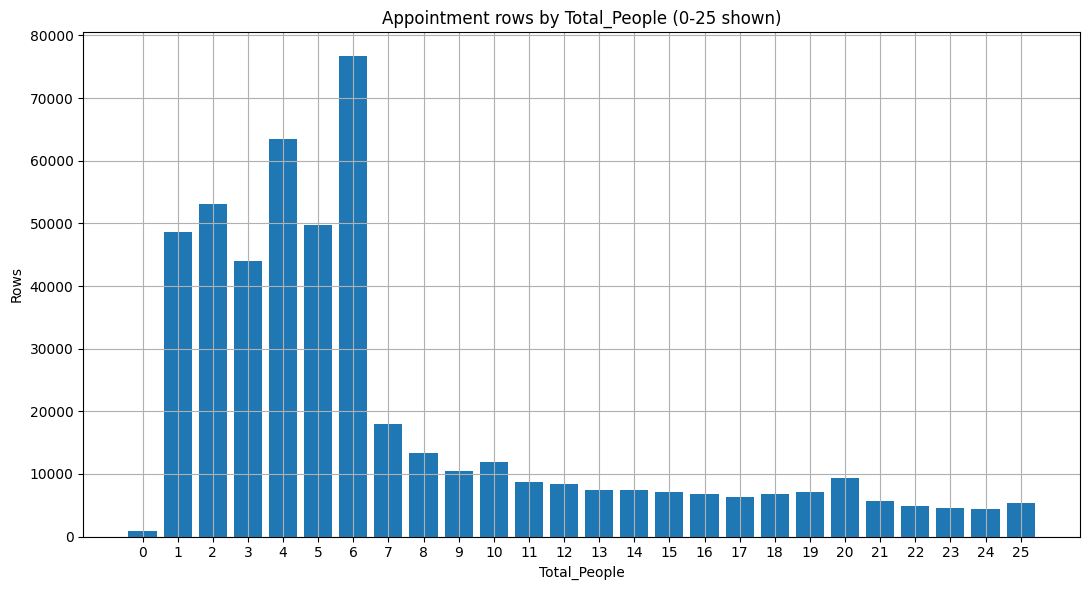

,total_people,row_count
0,0,815
1,1,48702
2,2,53149
3,3,44052
4,4,63440
5,5,49733
6,6,76664
7,7,17941
8,8,13354
9,9,10532


In [26]:
group_size_df = con.execute("""
SELECT
    CAST(Total_People AS INTEGER) AS total_people,
    COUNT(*) AS row_count
FROM raw_visitors
WHERE Total_People IS NOT NULL
GROUP BY 1
ORDER BY 1
""").df()

plot_group = group_size_df[group_size_df["total_people"] <= 25]

plt.figure()
plt.bar(plot_group["total_people"].astype(str), plot_group["row_count"])
plt.title("Appointment rows by Total_People (0-25 shown)")
plt.xlabel("Total_People")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

group_size_df.head(20)


## 10. Identify the most frequent visitors

### Why are we doing this?
Entity frequency is one of the fastest ways to understand who dominates the dataset. In visitor logs, repeated names may correspond to staff-adjacent behavior, contractors, recurring meetings, or data entry patterns.

### What does this mean?
This chart is *not* telling us who is most important in reality. It is telling us who appears most often in the records. That distinction is important for responsible analytics teaching.

### Why does this matter?
This is a direct bridge from EDA to OLAP. "Top-N visitors" is one of the simplest and most intuitive analytical questions students can later express in SQL.


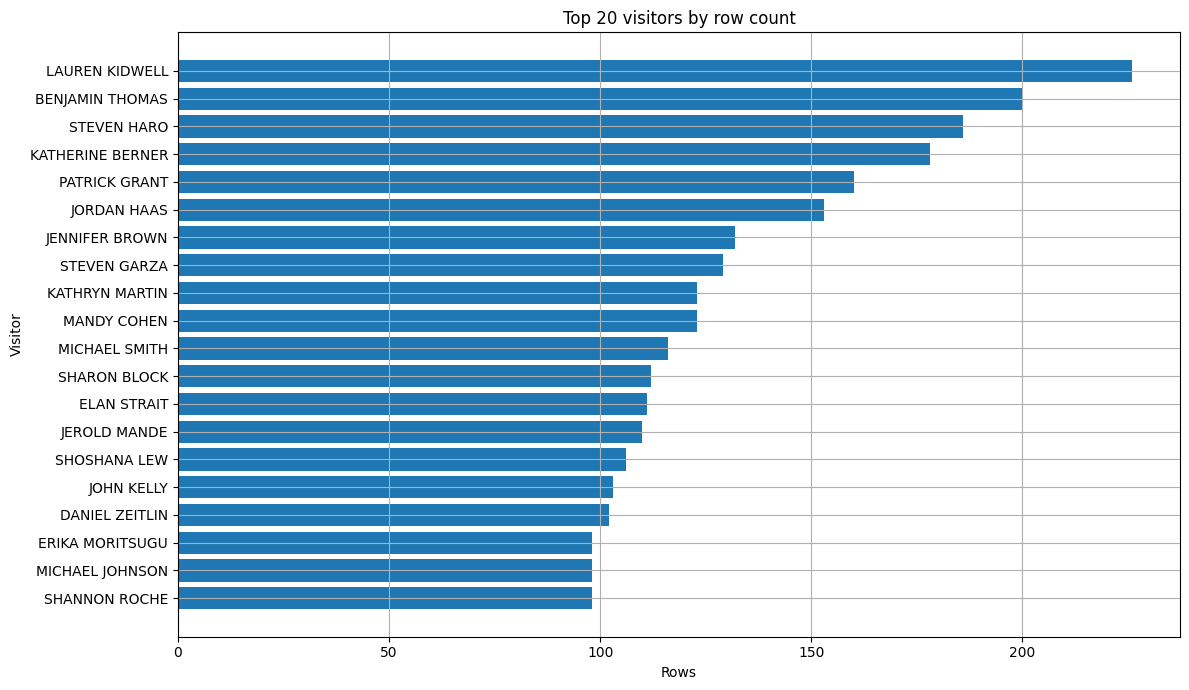

,visitor_name,visit_rows
0,LAUREN KIDWELL,226
1,BENJAMIN THOMAS,200
2,STEVEN HARO,186
3,KATHERINE BERNER,178
4,PATRICK GRANT,160
5,JORDAN HAAS,153
6,JENNIFER BROWN,132
7,STEVEN GARZA,129
8,KATHRYN MARTIN,123
9,MANDY COHEN,123


In [27]:
top_visitors = con.execute("""
SELECT
    upper(trim(NAMEFIRST)) || ' ' || upper(trim(NAMELAST)) AS visitor_name,
    COUNT(*) AS visit_rows
FROM raw_visitors
WHERE coalesce(trim(NAMEFIRST), '') <> ''
  AND coalesce(trim(NAMELAST), '') <> ''
GROUP BY 1
ORDER BY 2 DESC, 1
LIMIT 20
""").df()

plt.figure(figsize=(12, 7))
plt.barh(top_visitors["visitor_name"][::-1], top_visitors["visit_rows"][::-1])
plt.title("Top 20 visitors by row count")
plt.xlabel("Rows")
plt.ylabel("Visitor")
plt.tight_layout()
plt.show()

top_visitors.head(10)


## 11. Identify the most frequent visitees

### Why are we doing this?
The `visitee_*` fields tell us who inside the complex the visitor was scheduled to meet. This is the counterpart to visitor analysis.

### What does this mean?
Repeated visitee names can reveal which internal individuals or offices appear most frequently in the operational logs.

### Why does this matter?
This field is often even more analytically useful than visitor name because it can become the basis for behavioral warehouse questions such as:
- who receives the most appointments,
- which offices attract the most traffic,
- how activity differs by location.


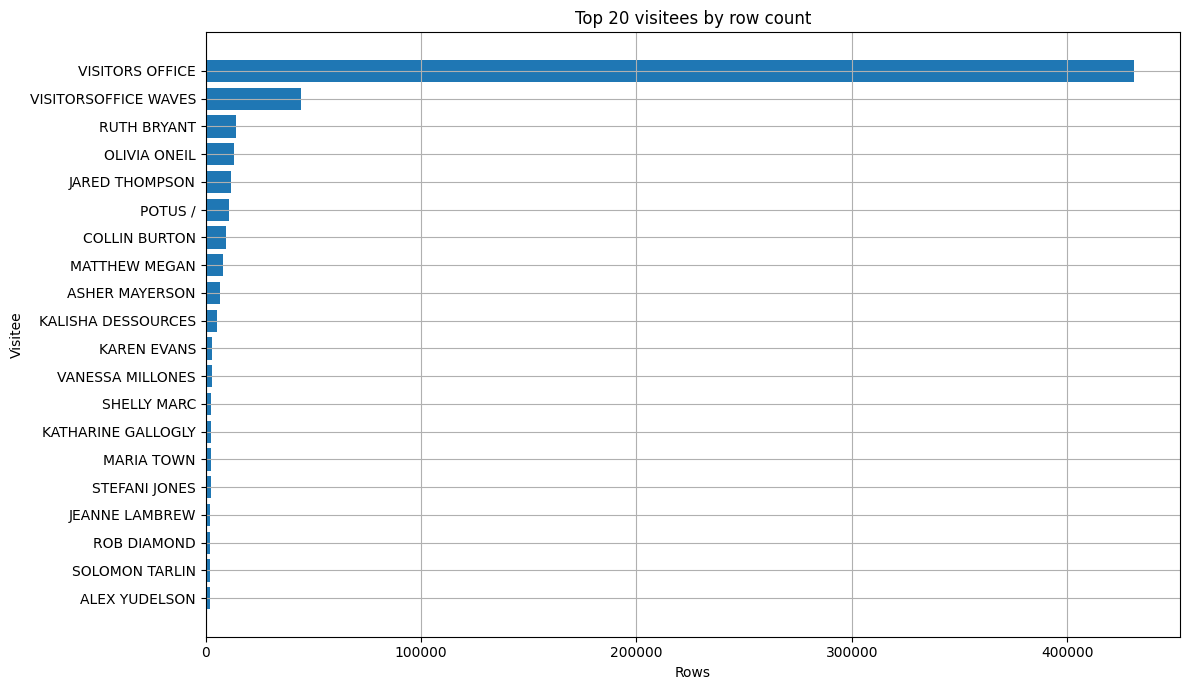

,visitee_name,visit_rows
0,VISITORS OFFICE,430881
1,VISITORSOFFICE WAVES,44129
2,RUTH BRYANT,13970
3,OLIVIA ONEIL,13155
4,JARED THOMPSON,11618
5,POTUS /,10900
6,COLLIN BURTON,9672
7,MATTHEW MEGAN,7944
8,ASHER MAYERSON,6886
9,KALISHA DESSOURCES,5289


In [28]:
top_visitees = con.execute("""
SELECT
    upper(trim(visitee_namefirst)) || ' ' || upper(trim(visitee_namelast)) AS visitee_name,
    COUNT(*) AS visit_rows
FROM raw_visitors
WHERE coalesce(trim(visitee_namefirst), '') <> ''
  AND coalesce(trim(visitee_namelast), '') <> ''
GROUP BY 1
ORDER BY 2 DESC, 1
LIMIT 20
""").df()

plt.figure(figsize=(12, 7))
plt.barh(top_visitees["visitee_name"][::-1], top_visitees["visit_rows"][::-1])
plt.title("Top 20 visitees by row count")
plt.xlabel("Rows")
plt.ylabel("Visitee")
plt.tight_layout()
plt.show()

top_visitees.head(10)


## 12. Look at the most common visitor-visitee pairs

### Why are we doing this?
A log file becomes much more interesting when we move from isolated entities to **relationships**. Pair analysis tells us which visitor-to-visitee combinations occur most often.

### What does this mean?
This is the beginning of behavioral analytics. Instead of only asking "who appears often?", we ask "which relationship patterns repeat?"

### Why does this matter?
This is exactly the type of question that motivates a fact table in a warehouse. A good fact table makes pair-level analysis easy and repeatable.


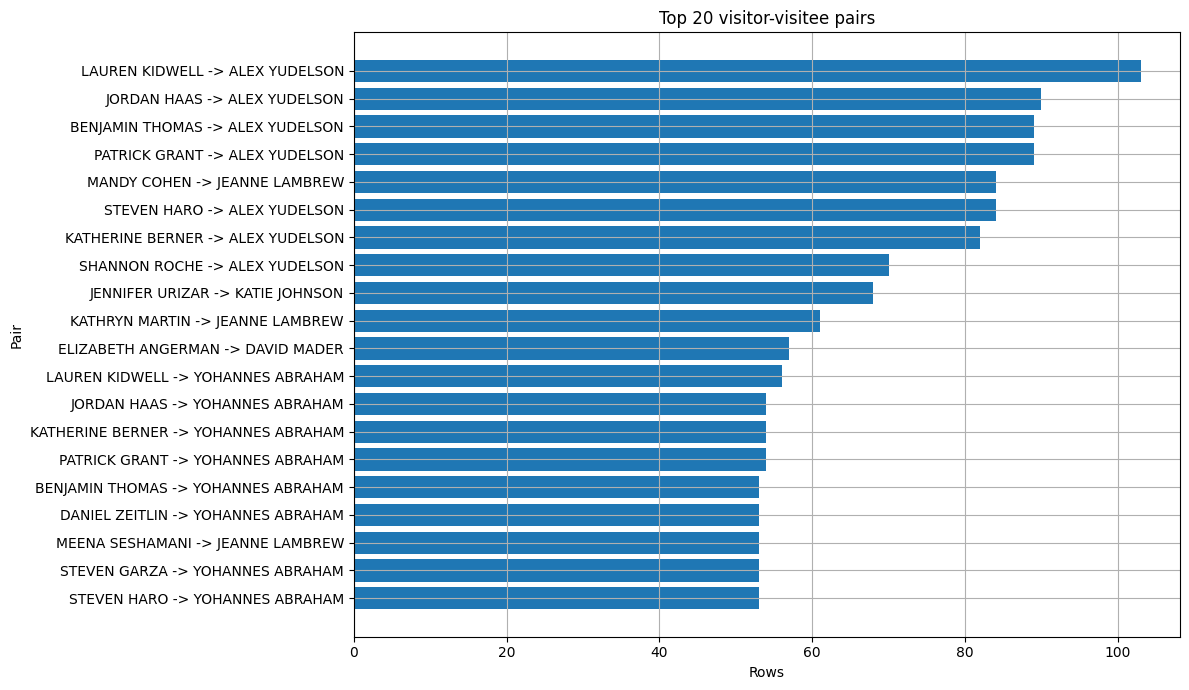

,visitor_name,visitee_name,pair_rows,pair_label
0,LAUREN KIDWELL,ALEX YUDELSON,103,LAUREN KIDWELL -> ALEX YUDELSON
1,JORDAN HAAS,ALEX YUDELSON,90,JORDAN HAAS -> ALEX YUDELSON
2,BENJAMIN THOMAS,ALEX YUDELSON,89,BENJAMIN THOMAS -> ALEX YUDELSON
3,PATRICK GRANT,ALEX YUDELSON,89,PATRICK GRANT -> ALEX YUDELSON
4,MANDY COHEN,JEANNE LAMBREW,84,MANDY COHEN -> JEANNE LAMBREW
5,STEVEN HARO,ALEX YUDELSON,84,STEVEN HARO -> ALEX YUDELSON
6,KATHERINE BERNER,ALEX YUDELSON,82,KATHERINE BERNER -> ALEX YUDELSON
7,SHANNON ROCHE,ALEX YUDELSON,70,SHANNON ROCHE -> ALEX YUDELSON
8,JENNIFER URIZAR,KATIE JOHNSON,68,JENNIFER URIZAR -> KATIE JOHNSON
9,KATHRYN MARTIN,JEANNE LAMBREW,61,KATHRYN MARTIN -> JEANNE LAMBREW


In [29]:
pair_df = con.execute("""
SELECT
    upper(trim(NAMEFIRST)) || ' ' || upper(trim(NAMELAST)) AS visitor_name,
    upper(trim(visitee_namefirst)) || ' ' || upper(trim(visitee_namelast)) AS visitee_name,
    COUNT(*) AS pair_rows
FROM raw_visitors
WHERE coalesce(trim(NAMEFIRST), '') <> ''
  AND coalesce(trim(NAMELAST), '') <> ''
  AND coalesce(trim(visitee_namefirst), '') <> ''
  AND coalesce(trim(visitee_namelast), '') <> ''
GROUP BY 1, 2
ORDER BY 3 DESC, 1, 2
LIMIT 20
""").df()

pair_df["pair_label"] = pair_df["visitor_name"] + " -> " + pair_df["visitee_name"]

plt.figure(figsize=(12, 7))
plt.barh(pair_df["pair_label"][::-1], pair_df["pair_rows"][::-1])
plt.title("Top 20 visitor-visitee pairs")
plt.xlabel("Rows")
plt.ylabel("Pair")
plt.tight_layout()
plt.show()

pair_df.head(10)


## 13. Evaluate missing visitor and visitee identity

### Why are we doing this?
Before building a warehouse centered on behavioral interactions, we need to know how often the essential actors are missing.

### What does this mean?
Rows without a defined visitor or defined visitee may still be useful in Bronze, but they are harder to interpret in a behavioral fact table.

### Why does this matter?
This exploration directly informs later Silver decisions:
- Should we drop anonymous rows from the main fact pipeline?
- Should we quarantine them into an audit table?
- Should we keep them only for completeness reporting?


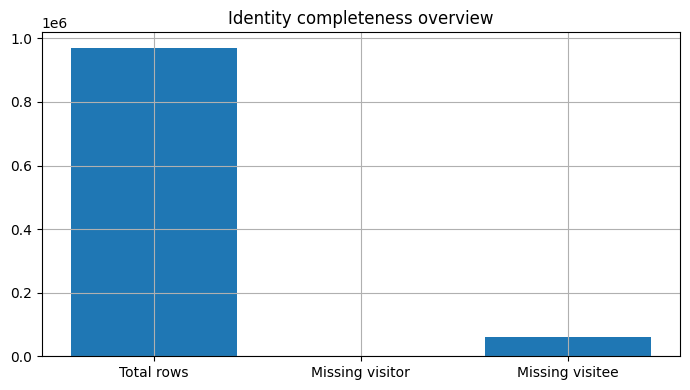

,total_rows,missing_visitor_identity_rows,missing_visitee_identity_rows
0,970498,0,61799


In [30]:
identity_quality = con.execute("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (
        WHERE coalesce(trim(NAMEFIRST), '') = '' OR coalesce(trim(NAMELAST), '') = ''
    ) AS missing_visitor_identity_rows,
    COUNT(*) FILTER (
        WHERE coalesce(trim(visitee_namefirst), '') = '' OR coalesce(trim(visitee_namelast), '') = ''
    ) AS missing_visitee_identity_rows
FROM raw_visitors
""").df()

vals = identity_quality.iloc[0]
plt.figure(figsize=(7,4))
plt.bar(
    ["Total rows", "Missing visitor", "Missing visitee"],
    [vals["total_rows"], vals["missing_visitor_identity_rows"], vals["missing_visitee_identity_rows"]]
)
plt.title("Identity completeness overview")
plt.tight_layout()
plt.show()

identity_quality


## 14. Compare canceled vs non-canceled appointments

### Why are we doing this?
Cancellation is a business-process outcome. It tells us whether the scheduled appointment actually remained active in the system.

### What does this mean?
A non-null cancellation date suggests the appointment was canceled. That allows us to study not only traffic volume but also process quality and workflow outcomes.

### Why does this matter?
This is valuable for both EDA and warehousing because later Gold models may include cancellation flags, rates, and trends as operational KPIs.


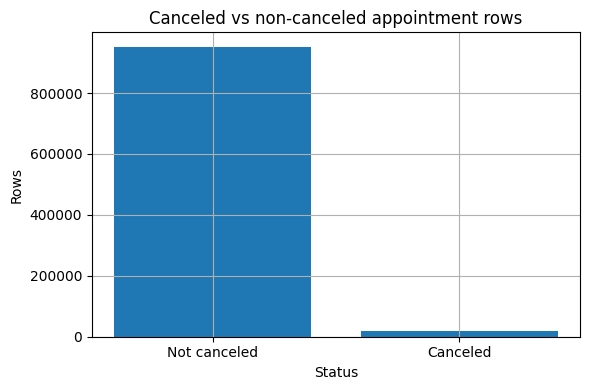

,cancel_status,row_count
0,Not canceled,951630
1,Canceled,18868


In [31]:
cancel_df = con.execute("""
SELECT
    CASE
        WHEN APPT_CANCEL_DATE IS NULL OR trim(APPT_CANCEL_DATE) = '' THEN 'Not canceled'
        ELSE 'Canceled'
    END AS cancel_status,
    COUNT(*) AS row_count
FROM raw_visitors
GROUP BY 1
ORDER BY 2 DESC
""").df()

plt.figure(figsize=(6,4))
plt.bar(cancel_df["cancel_status"], cancel_df["row_count"])
plt.title("Canceled vs non-canceled appointment rows")
plt.xlabel("Status")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

cancel_df


## 15. Release-date perspective

### Why are we doing this?
The file contains a `Release_Date`, which is different from the appointment date. That means the dataset includes both an **operational event date** and a **public release date**.

### What does this mean?
This distinction is excellent for teaching because it introduces the idea that one record can have multiple time meanings:
- when the activity was scheduled,
- when the record was updated,
- when the record was publicly released.

### Why does this matter?
This is a classic warehousing lesson. Good models keep different business times separate rather than collapsing them into one generic date field.


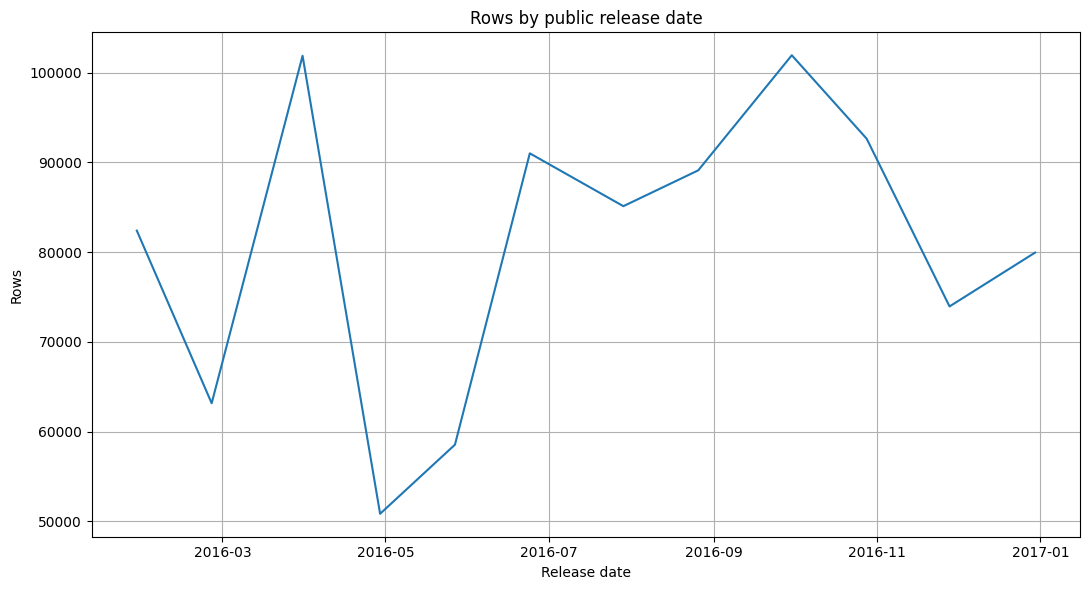

,release_date,row_count
0,2016-01-29,82393
1,2016-02-26,63163
2,2016-03-31,101869
3,2016-04-29,50849
4,2016-05-27,58549


In [32]:
release_df = con.execute("""
SELECT
    strptime(Release_Date, '%m/%d/%Y')::DATE AS release_date,
    COUNT(*) AS row_count
FROM raw_visitors
WHERE Release_Date IS NOT NULL
  AND trim(Release_Date) <> ''
GROUP BY 1
ORDER BY 1
""").df()

plt.figure()
plt.plot(release_df["release_date"], release_df["row_count"])
plt.title("Rows by public release date")
plt.xlabel("Release date")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

release_df.head()


# EDA Summary

At this point, we have learned the following:

1. The file is large enough to feel realistic, but still manageable in DuckDB on a laptop.
2. Several columns are sparse, which is a strong reason to separate Bronze from Silver.
3. Duplicate and identity-quality checks give us evidence for later cleaning rules.
4. Time, visitor, visitee, and location are the strongest candidates for Gold-layer analytics.
5. `Total_People` and cancellation status can become useful measures and KPIs.

## Recommended next step
Move from exploration to a **Medallion Architecture notebook**:
- **Bronze:** preserve the raw file faithfully,
- **Silver:** standardize, deduplicate, and quarantine problematic rows,
- **Gold:** build a behavioral analytics warehouse and answer OLAP questions.
